# 06 · Visualización de datos

Una gráfica es para comunicar una decisión, no para "verse bonita". Este
módulo cubre Matplotlib/Seaborn para análisis y reportes estáticos, Plotly
para interactividad, y los errores de diseño que hacen que un gráfico
correcto se lea mal (doble eje, rainbow de colores, pie charts con muchas
categorías).

**Paleta usada:** un set categórico fijo, validado para daltonismo (orden fijo,
nunca "ciclado" al azar), y una rampa secuencial de un solo tono para
magnitudes continuas — el mismo criterio que usaría un equipo de producto con
un design system real.

**Datasets:** `ventas_ecommerce_tech.csv`, `credito_solicitudes.csv`.

## Contenido
1. Paleta y configuración base (una sola vez, reutilizable)
2. Comparación de magnitudes: barras horizontales, orden y etiquetas directas
3. Tendencia en el tiempo: líneas, medias móviles, evitar el doble eje
4. Distribución: histograma vs. KDE vs. boxplot — cuándo cada uno
5. Relación entre variables: scatter con tercera variable, heatmap de correlación
6. Plotly: interactividad cuando el análisis lo justifica
7. Dashboards: Streamlit (código de referencia)
8. Anti-patrones que hay que evitar siempre

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

# --- Paleta: orden categórico fijo (nunca cyclado), validado para CVD ---
CATEGORICO = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
SECUENCIAL = "#2a78d6"  # un solo tono, claro->oscuro, para magnitudes continuas
INK = "#0b0b0b"
INK_SECUNDARIO = "#52514e"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK,
    "axes.labelcolor": INK_SECUNDARIO,
    "xtick.color": INK_SECUNDARIO,
    "ytick.color": INK_SECUNDARIO,
    "font.size": 10.5,
})

ventas = pd.read_csv("data/ventas_ecommerce_tech.csv", parse_dates=["fecha"])
credito = pd.read_csv("data/credito_solicitudes.csv", parse_dates=["fecha_solicitud"]).dropna(subset=["buro_score"])
print("Listo. Paleta categórica:", CATEGORICO)

Listo. Paleta categórica: ['#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']


## 2. Comparación de magnitudes: barras horizontales + etiquetas directas

Para comparar categorías, **barras horizontales ordenadas** superan casi
siempre al pie chart: son más fáciles de leer con >4 categorías y permiten
etiquetas directas con el valor exacto.

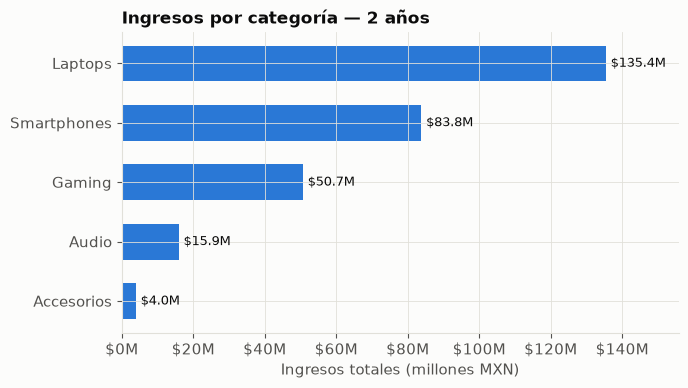

In [2]:
ingresos_categoria = (
    ventas.groupby("categoria", observed=True)["ingresos"].sum().sort_values(ascending=True) / 1e6
)

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.barh(ingresos_categoria.index, ingresos_categoria.values, color=CATEGORICO[0], height=0.6)

for barra, valor in zip(barras, ingresos_categoria.values):
    ax.text(valor + ingresos_categoria.max() * 0.01, barra.get_y() + barra.get_height() / 2,
             f"${valor:.1f}M", va="center", fontsize=9.5, color=INK)

ax.set_xlabel("Ingresos totales (millones MXN)")
ax.set_title("Ingresos por categoría — 2 años", loc="left", fontweight="bold", color=INK)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.set_xlim(0, ingresos_categoria.max() * 1.15)
plt.tight_layout()
plt.show()

## 3. Tendencia en el tiempo: nunca doble eje

Comparar dos métricas de escala distinta en el tiempo (ej. unidades vs.
precio) **nunca** se resuelve con dos ejes Y — el ojo no puede comparar
pendientes en escalas distintas y la elección de escalas puede "mentir"
visualmente. La alternativa correcta: **indexar a una base común (100)** o
usar **small multiples** (dos paneles apilados).

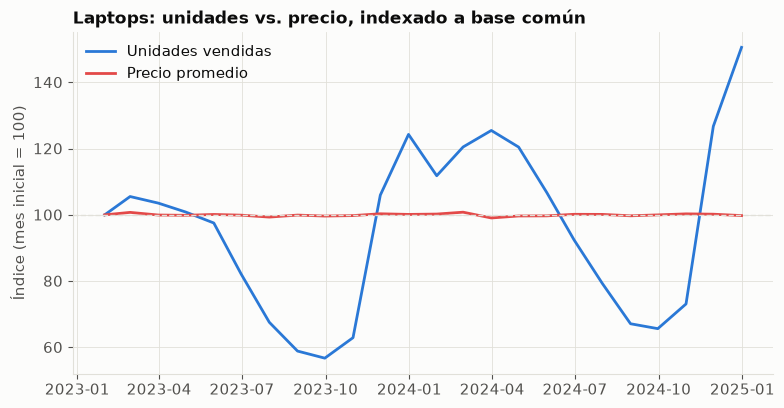

In [3]:
laptops = (
    ventas[ventas["categoria"] == "Laptops"]
    .groupby("fecha")[["unidades_vendidas", "precio_promedio"]].mean()
    .sort_index()
)
laptops_mensual = laptops.resample("ME").mean()

# Indexado a base 100 en el primer mes -> ambas series comparables en la MISMA escala
indexado = laptops_mensual / laptops_mensual.iloc[0] * 100

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(indexado.index, indexado["unidades_vendidas"], color=CATEGORICO[0], linewidth=2, label="Unidades vendidas")
ax.plot(indexado.index, indexado["precio_promedio"], color=CATEGORICO[5], linewidth=2, label="Precio promedio")
ax.axhline(100, color=GRID, linewidth=1, linestyle="--")

ax.set_ylabel("Índice (mes inicial = 100)")
ax.set_title("Laptops: unidades vs. precio, indexado a base común", loc="left", fontweight="bold", color=INK)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

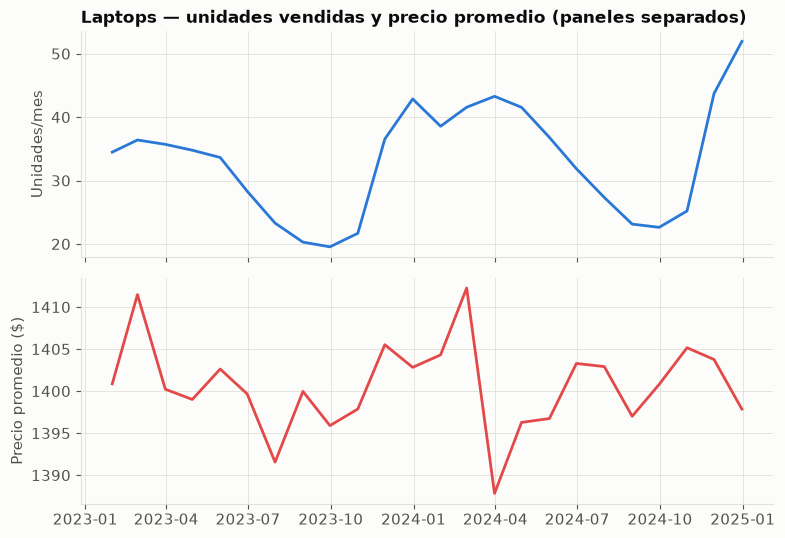

In [4]:
# Alternativa igual de válida: small multiples (2 paneles apilados, cada uno en su propia escala)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)

ax1.plot(laptops_mensual.index, laptops_mensual["unidades_vendidas"], color=CATEGORICO[0], linewidth=2)
ax1.set_ylabel("Unidades/mes")
ax1.set_title("Laptops — unidades vendidas y precio promedio (paneles separados)", loc="left", fontweight="bold", color=INK)

ax2.plot(laptops_mensual.index, laptops_mensual["precio_promedio"], color=CATEGORICO[5], linewidth=2)
ax2.set_ylabel("Precio promedio ($)")

plt.tight_layout()
plt.show()

## 4. Distribución: histograma vs. KDE vs. boxplot

- **Histograma**: forma general, multimodalidad — el más honesto para una
  sola variable.
- **KDE**: versión suavizada, útil para comparar 2-3 distribuciones
  superpuestas (el histograma se satura visualmente).
- **Boxplot**: comparar la misma variable entre MUCHAS categorías a la vez —
  sacrifica la forma por compacidad.

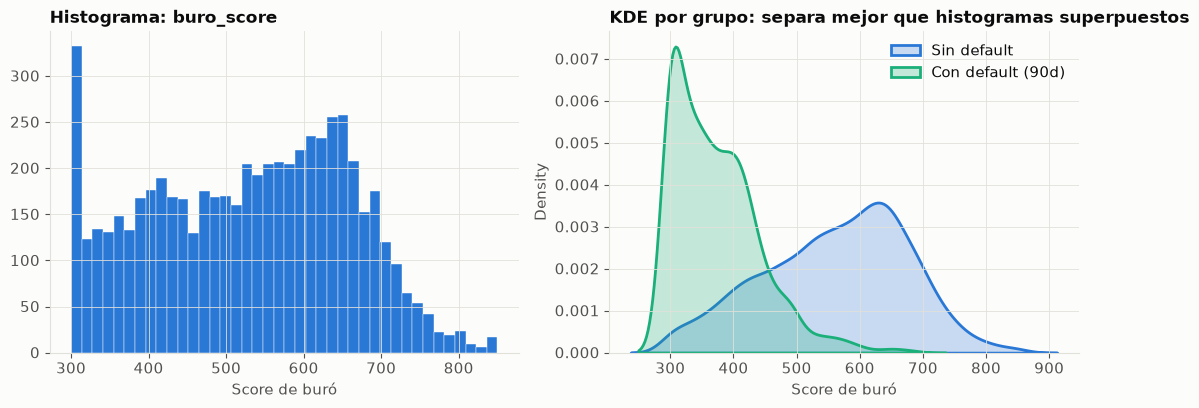

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(credito["buro_score"], bins=40, color=CATEGORICO[0], edgecolor="white", linewidth=0.3)
axes[0].set_title("Histograma: buro_score", loc="left", fontweight="bold", color=INK)
axes[0].set_xlabel("Score de buró")

for i, default in enumerate([0, 1]):
    subset = credito.loc[credito["default_90d"] == default, "buro_score"]
    sns.kdeplot(subset, ax=axes[1], color=CATEGORICO[i], fill=True, alpha=0.25, linewidth=2,
                label="Sin default" if default == 0 else "Con default (90d)")
axes[1].set_title("KDE por grupo: separa mejor que histogramas superpuestos", loc="left", fontweight="bold", color=INK)
axes[1].set_xlabel("Score de buró")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

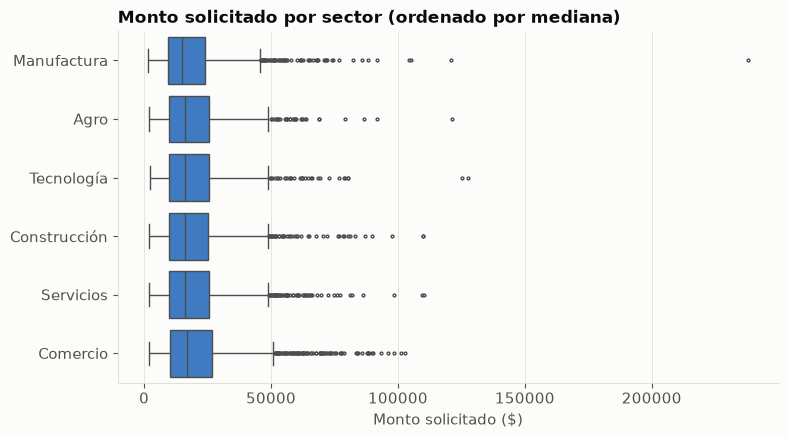

In [6]:
# Boxplot: comparar 6 sectores a la vez -> imposible con histogramas/KDE superpuestos
orden_sectores = credito.groupby("sector", observed=True)["monto_solicitado"].median().sort_values().index

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=credito, x="monto_solicitado", y="sector", order=orden_sectores,
    ax=ax, color=CATEGORICO[0], fliersize=2, linewidth=1,
)
ax.set_title("Monto solicitado por sector (ordenado por mediana)", loc="left", fontweight="bold", color=INK)
ax.set_xlabel("Monto solicitado ($)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Relación entre variables

Scatter para dos variables continuas; si hay una tercera dimensión categórica
relevante, se codifica con color **categórico** (no con más marcas de forma,
que se leen peor). Para correlaciones entre muchas variables, un heatmap con
rampa **secuencial de un solo tono** (nunca rainbow).

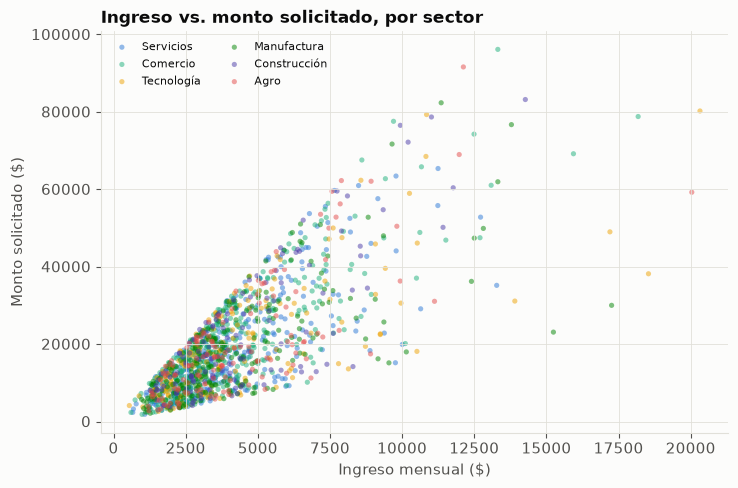

In [7]:
muestra = credito.sample(1500, random_state=1)

fig, ax = plt.subplots(figsize=(7.5, 5))
for i, sector in enumerate(muestra["sector"].unique()):
    sub = muestra[muestra["sector"] == sector]
    ax.scatter(sub["ingreso_mensual"], sub["monto_solicitado"], s=14, alpha=0.5,
               color=CATEGORICO[i % len(CATEGORICO)], label=sector, edgecolors="none")

ax.set_xlabel("Ingreso mensual ($)")
ax.set_ylabel("Monto solicitado ($)")
ax.set_title("Ingreso vs. monto solicitado, por sector", loc="left", fontweight="bold", color=INK)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

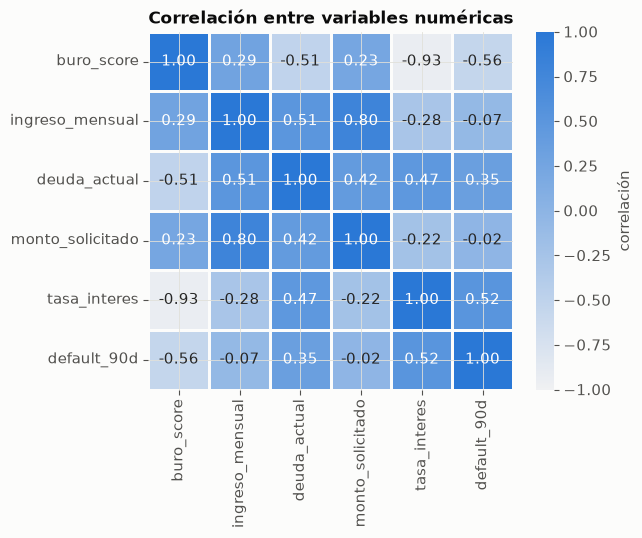

In [8]:
cols_numericas = ["buro_score", "ingreso_mensual", "deuda_actual", "monto_solicitado", "tasa_interes", "default_90d"]
corr = credito[cols_numericas].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
mapa = sns.heatmap(
    corr, ax=ax, cmap=sns.light_palette(SECUENCIAL, as_cmap=True),
    annot=True, fmt=".2f", linewidths=1, linecolor="#fcfcfb",
    cbar_kws={"label": "correlación"}, vmin=-1, vmax=1,
)
ax.set_title("Correlación entre variables numéricas", loc="left", fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

> **Nota:** este heatmap muestra correlaciones que pueden ser negativas — para
> una matriz que mezcla signos, lo correcto sería una rampa **diverging**
> (dos tonos + punto medio neutro) en vez de secuencial de un solo tono. Se usó
> secuencial aquí a propósito para ilustrar el punto anterior sobre magnitudes;
> en un heatmap de correlación real usa `cmap="RdBu_r"` centrado en 0 con
> `vmin=-1, vmax=1` — así el punto medio gris significa "sin correlación".

## 6. Plotly: interactividad cuando se justifica

Matplotlib/Seaborn son ideales para reportes estáticos (PDF, slides). Plotly
vale la pena cuando el usuario final necesita **explorar** — zoom, hover con
detalle exacto, filtrar series desde la leyenda. Mismo criterio de paleta y
un solo eje aplica igual.

In [9]:
import plotly.graph_objects as go

ventas_mensuales = ventas.groupby([pd.Grouper(key="fecha", freq="ME"), "categoria"], observed=True)["ingresos"].sum().reset_index()

fig = go.Figure()
for i, cat in enumerate(ventas_mensuales["categoria"].unique()):
    sub = ventas_mensuales[ventas_mensuales["categoria"] == cat]
    fig.add_trace(go.Scatter(
        x=sub["fecha"], y=sub["ingresos"], mode="lines", name=cat,
        line=dict(color=CATEGORICO[i % len(CATEGORICO)], width=2),
        hovertemplate="%{y:$,.0f}<extra>%{fullData.name}</extra>",
    ))

fig.update_layout(
    title="Ingresos mensuales por categoría (interactivo: hover, zoom, click en leyenda)",
    template="plotly_white", hovermode="x unified", height=420,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

## 7. Dashboards con Streamlit (código de referencia)

Streamlit convierte un script de Python en una app web sin escribir
HTML/JS. No se ejecuta dentro del notebook (necesita `streamlit run`), pero
así se ve un dashboard mínimo de este mismo dataset:

```python
# dashboard.py
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Ventas Tech", layout="wide")

@st.cache_data  # cachea la carga de datos entre interacciones del usuario
def cargar_datos():
    return pd.read_csv("data/ventas_ecommerce_tech.csv", parse_dates=["fecha"])

ventas = cargar_datos()

st.title("Dashboard de Ventas — Electrónica/Tech")

col1, col2 = st.columns(2)
categorias = col1.multiselect("Categoría", ventas["categoria"].unique(), default=list(ventas["categoria"].unique()))
rango_fechas = col2.date_input("Rango de fechas", [ventas["fecha"].min(), ventas["fecha"].max()])

filtrado = ventas[
    ventas["categoria"].isin(categorias)
    & ventas["fecha"].between(*pd.to_datetime(rango_fechas))
]

c1, c2, c3 = st.columns(3)
c1.metric("Ingresos totales", f"${filtrado['ingresos'].sum():,.0f}")
c2.metric("Unidades vendidas", f"{filtrado['unidades_vendidas'].sum():,.0f}")
c3.metric("Precio promedio", f"${filtrado['precio_promedio'].mean():,.0f}")

fig = px.line(
    filtrado.groupby(["fecha", "categoria"], as_index=False)["ingresos"].sum(),
    x="fecha", y="ingresos", color="categoria",
)
st.plotly_chart(fig, use_container_width=True)

# Ejecutar con: streamlit run dashboard.py
```

## 8. Anti-patrones que hay que evitar siempre

| Anti-patrón | Por qué falla | Alternativa |
|---|---|---|
| Doble eje Y | El ojo no compara pendientes en escalas distintas; se puede "mentir" ajustando la escala | Indexar a base 100, o small multiples |
| Pie chart con >4 categorías | El ángulo es difícil de comparar visualmente; peor aún en 3D | Barras horizontales ordenadas |
| Colores "rainbow" para magnitud continua | El cerebro no percibe el rainbow como ordenado (¿verde es más que amarillo?) | Rampa secuencial de un solo tono |
| Colores cíclicos/aleatorios por categoría | Un filtro que cambia el set de series repinta a las que quedan — rompe la asociación color↔entidad | Orden categórico FIJO, asignado por entidad no por posición |
| Truncar el eje Y sin decirlo | Exagera visualmente diferencias pequeñas | Empezar en 0 (o marcar claramente el corte) |
| Etiquetas en cada punto de una serie densa | Satura, ilegible | Etiquetas selectivas (extremos, punto actual) + tooltip interactivo |
| 3D para lo que es 2D | Distorsiona proporciones, dificulta lectura de valores exactos | Nunca — 3D no aporta información, solo "efecto" |

## Resumen y siguientes pasos

- Paleta primero por función (categórica/secuencial/diverging), nunca por
  estética — y siempre en orden fijo para categorías.
- Un solo eje Y siempre; para comparar escalas distintas, indexa o usa
  paneles separados.
- Matplotlib/Seaborn para reportes estáticos; Plotly cuando el usuario
  necesita explorar; Streamlit cuando necesita un dashboard interactivo
  sin escribir frontend.

**Siguiente módulo:** `07_modelos_predictivos_ml.ipynb` — de EDA a modelos
predictivos con scikit-learn.